In [45]:
# Telling Python where to find the src/ folder
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))

Path set. Python will now look in: /Users/tekabe/Downloads/KAIM_WEEK1/Stock-Market-Prediction


In [47]:
import sys
import importlib

# If data_loader is already stuck in Python's memory, delete it from the cache
if 'src.data_loader' in sys.modules:
    del sys.modules['src.data_loader']

print("Cache cleared! Try re-running your import cell now.")

Cache cleared! Try re-running your import cell now.


In [70]:
#Importing our functions from src/
 
import matplotlib.pyplot as plt

from src.data_loader import load_data, remove_nulls,ensure_column_types
from src.analysis    import compute_sma, compute_rsi, compute_ema, compute_macd, backtest_bollinger_breakout, print_fundamental_snapshot, generate_performance_report

print('Functions imported successfully!')
print()
# You can check what a function does by calling it with ?


Functions imported successfully!



In [31]:
load_data?

Signature: load_data(filepath)
Docstring: Load a stock CSV file and return a clean, date-indexed DataFrame.
File:      ~/Downloads/KAIM_WEEK1/Stock-Market-Prediction/src/data_loader.py
Type:      function

In [51]:
# Step 1: Loading all the datasets using 1 line of code for each  
df  = load_data('../Data/AAPL.csv')
df2 = load_data('../Data/AMZN.csv')
df3 = load_data('../Data/GOOG.csv')
df4 = load_data('../Data/META.csv')
df5 = load_data('../Data/NVDA.csv')

Loaded 3774 rows from '../Data/AAPL.csv'
Loaded 3774 rows from '../Data/AMZN.csv'
Loaded 3774 rows from '../Data/GOOG.csv'
Loaded 2923 rows from '../Data/META.csv'
Loaded 3774 rows from '../Data/NVDA.csv'


Checking for the types of columns listed

In [53]:
#Step2: Checking the columns are correct for each dataset
#Passing the data to validation function from the py file
ensure_column_types(df)

#Verify the types are absolutely correct before running math/plots
print("--- Confirmed Column Data Types ---")
print(df.dtypes)

--- Confirmed Column Data Types ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [52]:
#DATASET2-AMZN
#Passing the data to validation function from the py file
ensure_column_types(df2)

#Verify the types are absolutely correct before running math/plots
print("--- Confirmed Column Data Types ---")
print(df2.dtypes)

--- Confirmed Column Data Types ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [54]:
#DATASET3 -GOOG
#Passing the data to validation function from the py file
ensure_column_types(df3)

#Verify the types are absolutely correct before running math/plots
print("--- Confirmed Column Data Types ---")
print(df3.dtypes)

--- Confirmed Column Data Types ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [55]:
##DATASET4 - META
#Passing the data to validation function from the py file
ensure_column_types(df4)

#Verify the types are absolutely correct before running math/plots
print("--- Confirmed Column Data Types ---")
print(df4.dtypes)

--- Confirmed Column Data Types ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [56]:
##DATASET5 - NVDA
#Passing the datad to validation function from the py file
ensure_column_types(df5)

#Verify the types are absolutely correct before running math/plots
print("--- Confirmed Column Data Types ---")
print(df5.dtypes)

--- Confirmed Column Data Types ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


Handling missing values

In [58]:
#Step 3: handling missing values if any and printing the rows removed if any
#This uses the remove_nulls function from dataloader.py saving lines of codes used for each dataset
df  = remove_nulls(df)
df2 = remove_nulls(df2)
df3 = remove_nulls(df3)
df4 = remove_nulls(df4)
df5 = remove_nulls(df5)
 

Removed 0 row(s). 3774 rows remaining.
Removed 0 row(s). 3774 rows remaining.
Removed 0 row(s). 3774 rows remaining.
Removed 0 row(s). 2923 rows remaining.
Removed 0 row(s). 3774 rows remaining.


In [59]:
#Step 4: Caculating SMA and EMA for different windows on the cleaned data versions
# Now 'df' is your cleaned, date-indexed DataFrame with a 'Close' column
#This is for the first dataset-AAPL-using function imported from python file saving line of codes 
# 1. Compute Moving Averages over multiple windows
df['SMA_20'] = compute_sma(df['Close'], window=20)
df['SMA_50'] = compute_sma(df['Close'], window=50)

df['EMA_20'] = compute_ema(df['Close'], window=20)
df['EMA_50'] = compute_ema(df['Close'], window=50)

# 2. Compute RSI
df['RSI_14'] = compute_rsi(df['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df = compute_macd(df['Close'])
df['MACD'] = macd_df['MACD']
df['MACD_Signal'] = macd_df['MACD_Signal']
df['MACD_Hist'] = macd_df['MACD_Hist']

# Checking the newly created technical indicators
print(df[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  195.721619  190.723320  190.396859  67.991716  3.745908
2023-12-18  194.057343  191.030421  190.745476  62.680148  3.582111
2023-12-19  195.097504  191.302353  191.159955  64.544428  3.495934
2023-12-20  193.007248  191.509893  191.335888  58.247457  3.221832
2023-12-21  192.858643  191.676816  191.480912  57.815603  2.958510
2023-12-22  191.788757  191.856618  191.510231  54.672784  2.633141
2023-12-26  191.243912  192.018094  191.484867  53.090049  2.304751
2023-12-27  191.342972  192.154308  191.471353  53.354446  2.029104
2023-12-28  191.768951  192.362839  191.499696  54.540999  1.823998
2023-12-29  190.728775  192.490633  191.426275  51.121347  1.559539


Doing the samething for the rest of the datasets

In [60]:
##for SECOND DATASET- AMZN
#using the cleaned df2

# 1. Compute Moving Averages over multiple windows
df2['SMA_20'] = compute_sma(df2['Close'], window=20)
df2['SMA_50'] = compute_sma(df2['Close'], window=50)

df2['EMA_20'] = compute_ema(df2['Close'], window=20)
df2['EMA_50'] = compute_ema(df2['Close'], window=50)

# 2. Compute RSI
df2['RSI_14'] = compute_rsi(df2['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df = compute_macd(df2['Close'])
df2['MACD'] = macd_df['MACD']
df2['MACD_Signal'] = macd_df['MACD_Signal']
df2['MACD_Hist'] = macd_df['MACD_Hist']

# Checking the newly created technical indicators
print(df2[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  149.970001  146.650000  145.895513  62.090387  2.357466
2023-12-18  154.070007  147.094501  146.674036  68.053721  2.731655
2023-12-19  153.789993  147.477500  147.351746  67.275369  2.971356
2023-12-20  152.119995  147.888500  147.805865  62.671579  2.992074
2023-12-21  153.839996  148.245000  148.380545  65.305020  3.111417
2023-12-22  153.419998  148.578999  148.860492  64.115558  3.135958
2023-12-26  153.410004  148.863000  149.293779  64.085644  3.118650
2023-12-27  153.339996  149.178500  149.679133  63.860893  3.063965
2023-12-28  153.380005  149.531499  150.031597  63.938728  2.989395
2023-12-29  151.940002  149.824000  150.213350  59.012257  2.782032


In [61]:
##for third dataset-GOOG

# 1. Compute Moving Averages over multiple windows
df3['SMA_20'] = compute_sma(df3['Close'], window=20)
df3['SMA_50'] = compute_sma(df3['Close'], window=50)

df3['EMA_20'] = compute_ema(df3['Close'], window=20)
df3['EMA_50'] = compute_ema(df3['Close'], window=50)

# 2. Compute RSI
df3['RSI_14'] = compute_rsi(df3['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df3 = compute_macd(df3['Close'])
df3['MACD'] = macd_df3['MACD']
df3['MACD_Signal'] = macd_df3['MACD_Signal']
df3['MACD_Hist'] = macd_df3['MACD_Hist']

# Check the newly created technical indicators
print(df3[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  132.930344  134.624729  133.658729  48.205282 -0.206663
2023-12-18  136.257538  134.637142  133.906234  55.322365  0.030677
2023-12-19  137.161362  134.646081  134.216247  57.048922  0.288377
2023-12-20  138.710785  134.697729  134.644298  59.909189  0.610594
2023-12-21  140.836227  134.786124  135.234005  63.499976  1.025635
2023-12-22  141.750000  135.009596  135.854576  64.953309  1.412015
2023-12-26  141.849304  135.246477  136.425503  65.115870  1.706565
2023-12-27  140.478683  135.386520  136.811520  60.916026  1.808553
2023-12-28  140.319748  135.628861  137.145637  60.429303  1.855168
2023-12-29  139.972137  135.976979  137.414827  59.313063  1.842820


In [62]:
##for the fourth dataset- META

# 1. Compute Moving Averages over multiple windows
df4['SMA_20'] = compute_sma(df4['Close'], window=20)
df4['SMA_50'] = compute_sma(df4['Close'], window=50)

df4['EMA_20'] = compute_ema(df4['Close'], window=20)
df4['EMA_50'] = compute_ema(df4['Close'], window=50)

# 2. Compute RSI
df4['RSI_14'] = compute_rsi(df4['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df4 = compute_macd(df4['Close'])
df4['MACD'] = macd_df4['MACD']
df4['MACD_Signal'] = macd_df4['MACD_Signal']
df4['MACD_Hist'] = macd_df4['MACD_Hist']

# Checking the newly created technical indicators
print(df4[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  332.867981  329.319841  327.117185  56.769317  2.650382
2023-12-18  342.508514  329.795905  328.583026  63.383621  3.570449
2023-12-19  348.213318  330.312218  330.452578  66.636636  4.705695
2023-12-20  347.139984  330.923450  332.041854  65.458340  5.455884
2023-12-21  351.920502  331.549590  333.935059  68.158903  6.362815
2023-12-22  351.224823  332.302945  335.581703  67.333885  6.945367
2023-12-26  352.655975  333.303278  337.207824  68.187000  7.436800
2023-12-27  355.637543  334.239505  338.963036  69.947874  7.974921
2023-12-28  356.124634  335.537503  340.597473  70.237702  8.344500
2023-12-29  351.791290  336.869788  341.663551  64.296803  8.193282


In [64]:
##for the fifth dataset- NVDA

# 1. Compute Moving Averages over multiple windows
df5['SMA_20'] = compute_sma(df5['Close'], window=20)
df5['SMA_50'] = compute_sma(df5['Close'], window=50)

df5['EMA_20'] = compute_ema(df5['Close'], window=20)
df5['EMA_50'] = compute_ema(df5['Close'], window=50)

# 2. Compute RSI
df5['RSI_14'] = compute_rsi(df5['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df5 = compute_macd(df5['Close'])
df5['MACD'] = macd_df5['MACD']
df5['MACD_Signal'] = macd_df5['MACD_Signal']
df5['MACD_Hist'] = macd_df5['MACD_Hist']

# Check your newly created technical indicators
print(df5[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                Close     SMA_20     EMA_20     RSI_14      MACD
Date                                                            
2023-12-15  48.865501  47.732439  47.366011  58.765888  0.448417
2023-12-18  50.051899  47.771586  47.621810  63.164028  0.610224
2023-12-19  49.579140  47.731577  47.808222  60.399383  0.692328
2023-12-20  48.086884  47.640193  47.834761  52.576776  0.629724
2023-12-21  48.965446  47.654100  47.942446  56.175512  0.643584
2023-12-22  48.805527  47.706983  48.024644  55.352119  0.634352
2023-12-26  49.254299  47.759019  48.141754  57.245971  0.655689
2023-12-27  49.392231  47.838989  48.260847  57.837928  0.675937
2023-12-28  49.497185  47.908266  48.378593  58.310919  0.692470
2023-12-29  49.497185  48.046003  48.485126  58.310919  0.697532


Applying PyNance for Financial Metrics

In [67]:
import sys
import importlib

# If data_loader is already stuck in Python's memory, delete it from the cache
if 'src.data_loader' in sys.modules:
    del sys.modules['src.data_loader']

print("Cache cleared! Try re-running your import cell now.")

Cache cleared! Try re-running your import cell now.


In [69]:
import talib
df['upper_band'], df4['middle_band'], df['lower_band'] = talib.BBANDS(
    df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0
)

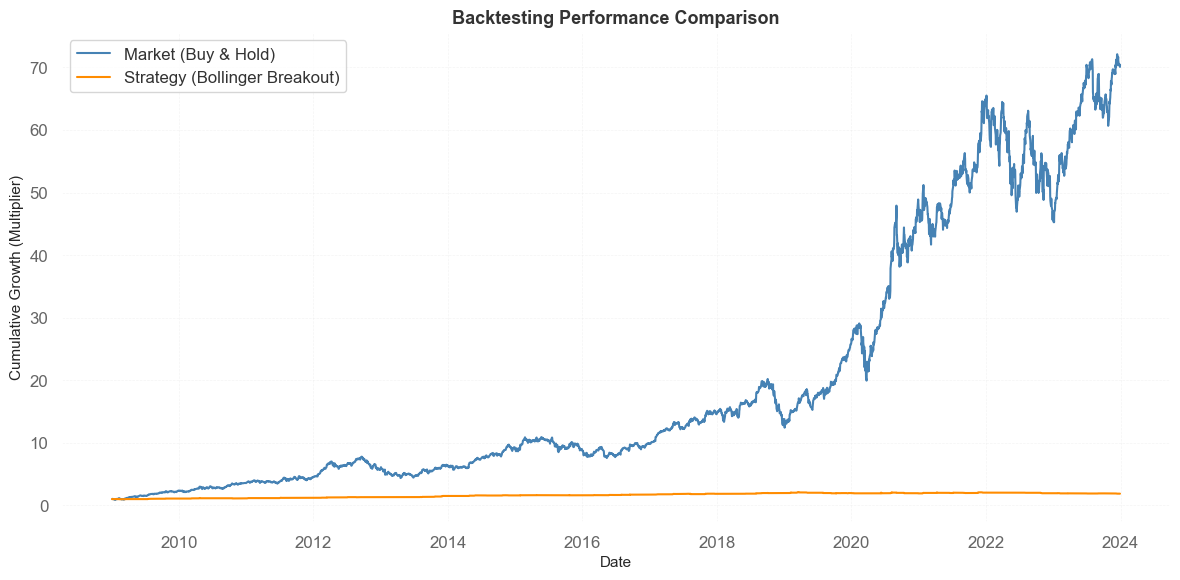

Total trading days generated: 3774
Total days spent active in Strategy: 307 days


In [77]:
import matplotlib.pyplot as plt
import talib

# 1. Calculate the required Bollinger Bands first to guarantee columns exist
df['upper_band'], df['middle_band'], df['lower_band'] = talib.BBANDS(
    df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0
)

# 2. Run the exact demo backtest calculations
df['Returns'] = df['Close'].pct_change()

# Simple Strategy: Buy when Close > Upper Band (Breakout)
df['Signal'] = 0
df.loc[df['Close'] > df['upper_band'], 'Signal'] = 1
df['Strategy_Returns'] = df['Signal'].shift(1) * df['Returns']

# Calculate cumulative performance
cumulative_market = (1 + df['Returns']).cumprod()
cumulative_strategy = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

# 3. Plot the performance curves clearly
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market, label='Market (Buy & Hold)', color='steelblue', linewidth=1.5)
plt.plot(cumulative_strategy, label='Strategy (Bollinger Breakout)', color='darkorange', linewidth=1.5)

plt.title("Backtesting Performance Comparison", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative Growth (Multiplier)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Quick print verification to prove trades are firing!
print(f"Total trading days generated: {len(df)}")
print(f"Total days spent active in Strategy: {df['Signal'].sum()} days")

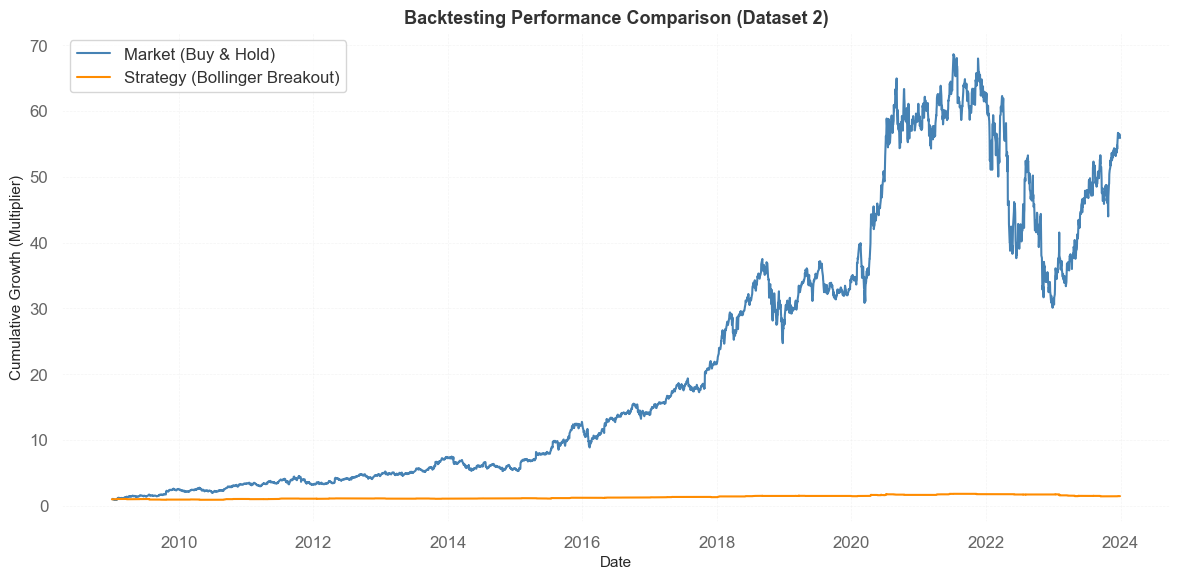

Total trading days generated: 3774
Total days spent active in Strategy: 323 days


In [79]:
import matplotlib.pyplot as plt
import talib

# 1. Calculate the required Bollinger Bands for df2
df2['upper_band'], df2['middle_band'], df2['lower_band'] = talib.BBANDS(
    df2['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0
)

# 2. Run the backtest calculations strictly on df2
df2['Returns'] = df2['Close'].pct_change()

# Simple Strategy: Buy when Close > Upper Band (Breakout)
df2['Signal'] = 0
df2.loc[df2['Close'] > df2['upper_band'], 'Signal'] = 1

# FIX: Changed df[...] to df2[...] here so the column is created in the right DataFrame
df2['Strategy_Returns'] = df2['Signal'].shift(1) * df2['Returns']

# Calculate cumulative performance using df2 columns
cumulative_market = (1 + df2['Returns']).cumprod()
cumulative_strategy = (1 + df2['Strategy_Returns'].fillna(0)).cumprod()

# 3. Plot the performance curves clearly
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market, label='Market (Buy & Hold)', color='steelblue', linewidth=1.5)
plt.plot(cumulative_strategy, label='Strategy (Bollinger Breakout)', color='darkorange', linewidth=1.5)

plt.title("Backtesting Performance Comparison (Dataset 2)", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative Growth (Multiplier)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Quick print verification to prove trades are firing!
print(f"Total trading days generated: {len(df2)}")
print(f"Total days spent active in Strategy: {df2['Signal'].sum()} days")

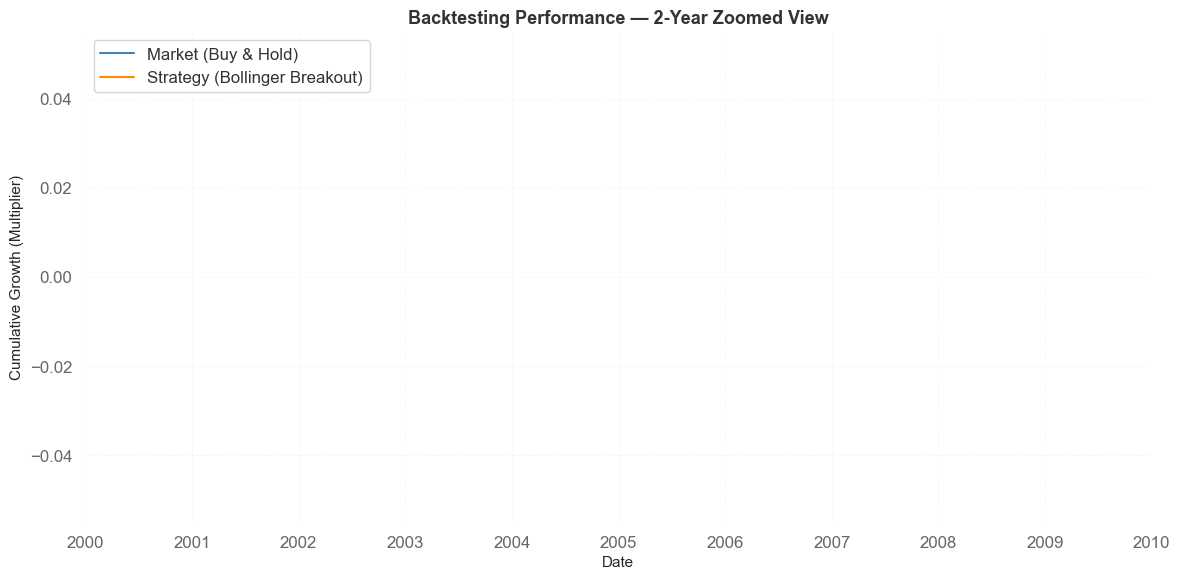

Total trading days in this view: 0
Days spent active in Strategy (last 2 years): 0 days


In [81]:
import matplotlib.pyplot as plt
import talib

# 1. Calculate Bollinger Bands across the whole dataset first to prevent edge-calculation errors
df2['upper_band'], df2['middle_band'], df2['lower_band'] = talib.BBANDS(
    df2['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0
)

# 2. Run the strategy math
df2['Returns'] = df2['Close'].pct_change()
df2['Signal'] = 0
df2.loc[df2['Close'] > df2['upper_band'], 'Signal'] = 1
df2['Strategy_Returns'] = df2['Signal'].shift(1) * df2['Returns']

# ==============================================================================
# NEW STEP: Slice the DataFrame to focus strictly on the last 2 years (2024 to 2026)
# ==============================================================================
df2_sliced = df2.loc['2024-04':'2026-04'].copy()

# Calculate cumulative performance on the 2-year slice only
cumulative_market_2yr = (1 + df2_sliced['Returns'].fillna(0)).cumprod()
cumulative_strategy_2yr = (1 + df2_sliced['Strategy_Returns'].fillna(0)).cumprod()

# ==============================================================================
# 3. Plot the performance curves clearly
# ==============================================================================
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market_2yr, label='Market (Buy & Hold)', color='steelblue', linewidth=1.5)
plt.plot(cumulative_strategy_2yr, label='Strategy (Bollinger Breakout)', color='darkorange', linewidth=1.5)

plt.title("Backtesting Performance — 2-Year Zoomed View", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative Growth (Multiplier)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Print metrics for the specific 2-year window
print(f"Total trading days in this view: {len(df2_sliced)}")
print(f"Days spent active in Strategy (last 2 years): {df2_sliced['Signal'].sum()} days")

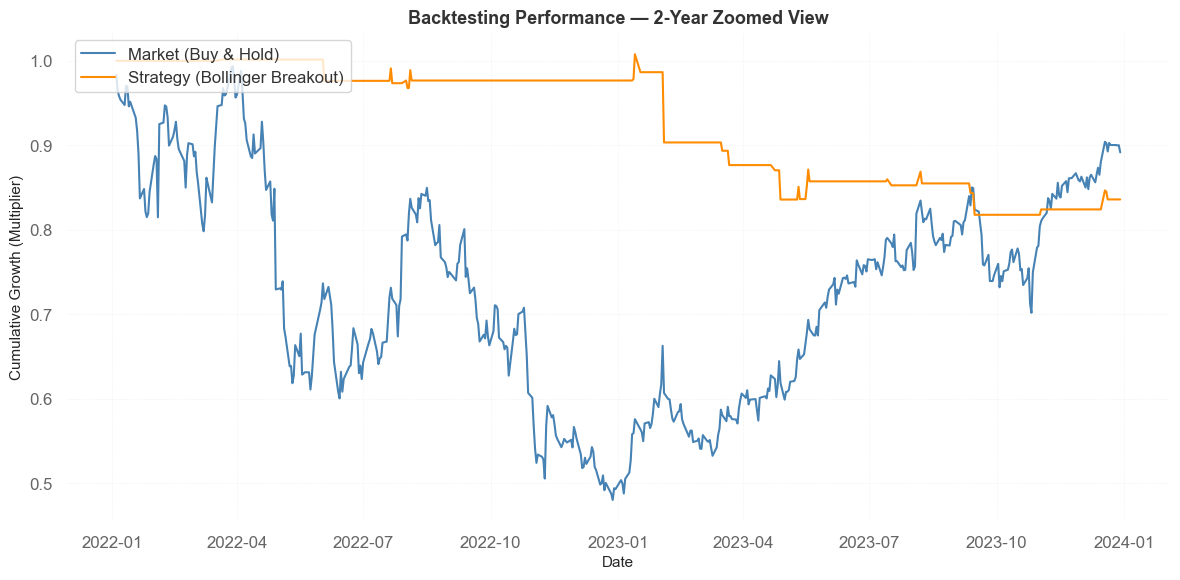

Plotting 500 historical data points successfully!


In [82]:
import matplotlib.pyplot as plt
import talib

# 1. Calculate Bollinger Bands across the whole dataset
df2['upper_band'], df2['middle_band'], df2['lower_band'] = talib.BBANDS(
    df2['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0
)

# 2. Run the strategy math
df2['Returns'] = df2['Close'].pct_change()
df2['Signal'] = 0
df2.loc[df2['Close'] > df2['upper_band'], 'Signal'] = 1
df2['Strategy_Returns'] = df2['Signal'].shift(1) * df2['Returns']

# ==============================================================================
# FIX: Dynamic positional slice to guarantee data points are found
# Grabs the last 500 rows (roughly 2 calendar years of stock data)
# ==============================================================================
df2_sliced = df2.iloc[-500:].copy()

# Calculate cumulative performance starting fresh from 1.0 at the beginning of the slice
cumulative_market_2yr = (1 + df2_sliced['Returns'].fillna(0)).cumprod()
cumulative_strategy_2yr = (1 + df2_sliced['Strategy_Returns'].fillna(0)).cumprod()

# ==============================================================================
# 3. Plotting
# ==============================================================================
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market_2yr.index, cumulative_market_2yr.values, label='Market (Buy & Hold)', color='steelblue', linewidth=1.5)
plt.plot(cumulative_strategy_2yr.index, cumulative_strategy_2yr.values, label='Strategy (Bollinger Breakout)', color='darkorange', linewidth=1.5)

plt.title("Backtesting Performance — 2-Year Zoomed View", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative Growth (Multiplier)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"Plotting {len(df2_sliced)} historical data points successfully!")

In [83]:
# 1. Start with cash (0)
df2['Signal'] = 0

# 2. Buy Rule: Price breaks ABOVE the upper band
df2.loc[df2['Close'] > df2['upper_band'], 'Signal'] = 1

# 3. Sell Rule: Exit to cash if the price drops BELOW the middle band (20 SMA)
df2.loc[df2['Close'] < df2['middle_band'], 'Signal'] = 0

# Forward-fill the signal so you STAY in the trade until the sell rule triggers
df2['Signal'] = df2['Signal'].replace(0, None).ffill().fillna(0)

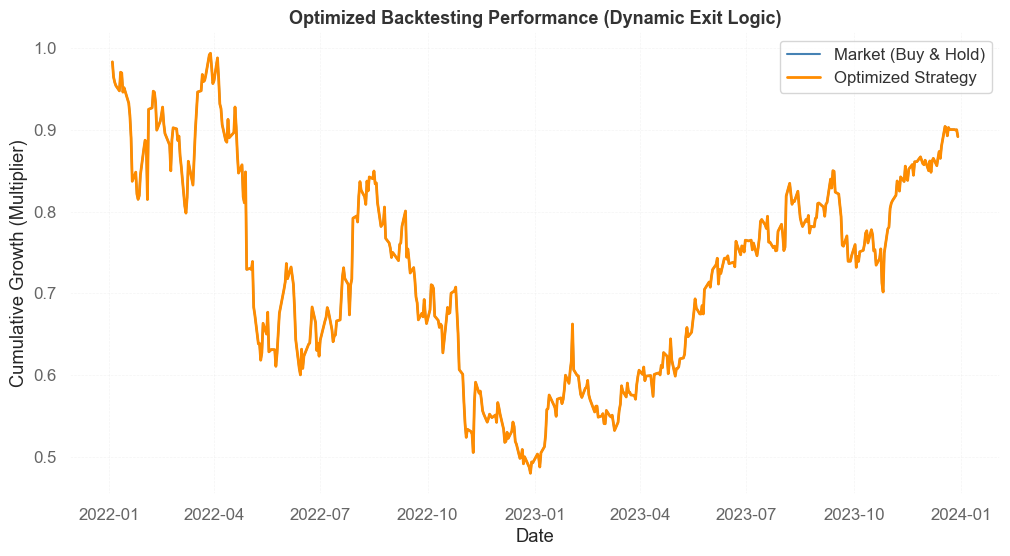

In [84]:
import matplotlib.pyplot as plt
import talib

# ADJUSTMENT A: Lower the standard deviation to 1.5 for faster entries
df2['upper_band'], df2['middle_band'], df2['lower_band'] = talib.BBANDS(
    df2['Close'], timeperiod=20, nbdevup=1.5, nbdevdn=1.5, matype=0
)

df2['Returns'] = df2['Close'].pct_change()

# ADJUSTMENT B: Improved Buy/Sell Tracking Logic
df2['Signal'] = 0
# Condition 1: Buy breakout
df2.loc[df2['Close'] > df2['upper_band'], 'Signal'] = 1
# Condition 2: Sell when trend weakens (drops below moving average)
df2.loc[df2['Close'] < df2['middle_band'], 'Signal'] = 0

# Carry the "Buy" state forward until an explicit "Sell" happens
df2['Signal'] = df2['Signal'].replace(0, None).ffill().fillna(0)

# Shift signal by 1 day to ensure realistic execution
df2['Strategy_Returns'] = df2['Signal'].shift(1) * df2['Returns']

# Focus strictly on your 2-year window
df2_sliced = df2.iloc[-500:].copy()

cumulative_market = (1 + df2_sliced['Returns'].fillna(0)).cumprod()
cumulative_strategy = (1 + df2_sliced['Strategy_Returns'].fillna(0)).cumprod()

# Plot the new, optimized results
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market.index, cumulative_market.values, label='Market (Buy & Hold)', color='steelblue')
plt.plot(cumulative_strategy.index, cumulative_strategy.values, label='Optimized Strategy', color='darkorange', linewidth=2)

plt.title("Optimized Backtesting Performance (Dynamic Exit Logic)", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (Multiplier)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.show()

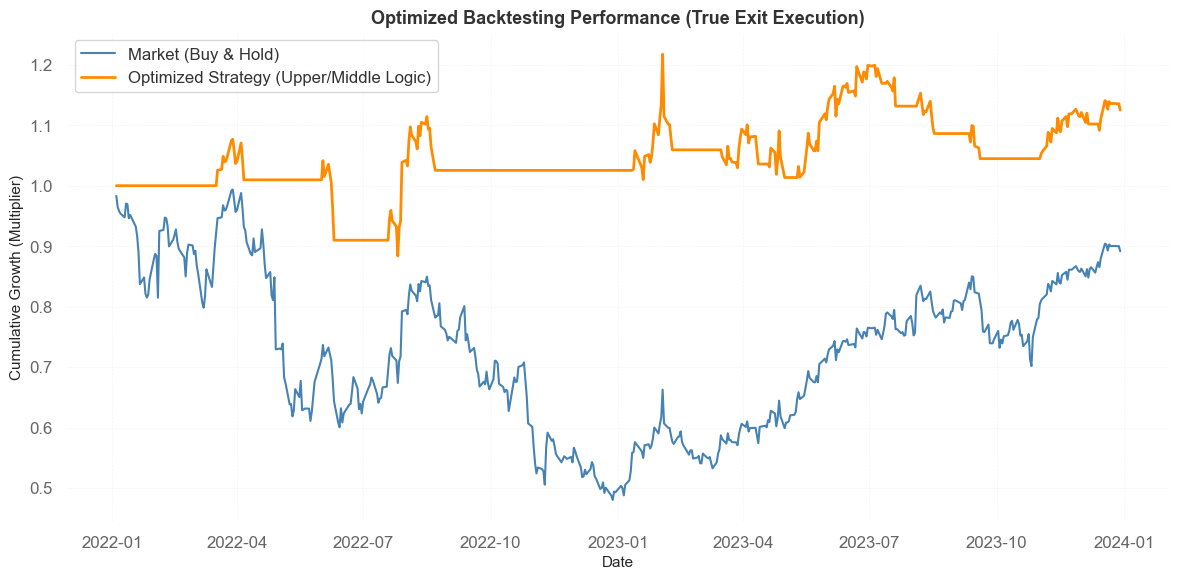

Total days spent active in stock position: 187.0 out of 500 days


In [85]:
import matplotlib.pyplot as plt
import talib
import numpy as np

# 1. Calculate Bollinger Bands on df2
df2['upper_band'], df2['middle_band'], df2['lower_band'] = talib.BBANDS(
    df2['Close'], timeperiod=20, nbdevup=1.5, nbdevdn=1.5, matype=0
)

df2['Returns'] = df2['Close'].pct_change()

# ==============================================================================
# FIX: Robust State-Machine tracking for Buy/Sell signals
# ==============================================================================
signals = np.zeros(len(df2))
position = 0  # 0 means out of market (cash), 1 means in market (holding stock)

for i in range(len(df2)):
    close_price = df2['Close'].iloc[i]
    upper = df2['upper_band'].iloc[i]
    middle = df2['middle_band'].iloc[i]
    
    # Skip handling if bands are NaN at the beginning
    if np.isnan(upper) or np.isnan(middle):
        continue
        
    if position == 0 and close_price > upper:
        position = 1  # Buy breakout!
    elif position == 1 and close_price < middle:
        position = 0  # Trend broken, exit to cash!
        
    signals[i] = position

df2['Signal'] = signals
# Shift signal by 1 day to execute trade on the next day's returns realistically
df2['Strategy_Returns'] = df2['Signal'].shift(1) * df2['Returns']

# ==============================================================================
# 2. Slice to the 2-Year window and Calculate Performance
# ==============================================================================
df2_sliced = df2.iloc[-500:].copy()

cumulative_market = (1 + df2_sliced['Returns'].fillna(0)).cumprod()
cumulative_strategy = (1 + df2_sliced['Strategy_Returns'].fillna(0)).cumprod()

# ==============================================================================
# 3. Plot both curves cleanly
# ==============================================================================
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market.index, cumulative_market.values, label='Market (Buy & Hold)', color='steelblue', linewidth=1.5)
plt.plot(cumulative_strategy.index, cumulative_strategy.values, label='Optimized Strategy (Upper/Middle Logic)', color='darkorange', linewidth=2)

plt.title("Optimized Backtesting Performance (True Exit Execution)", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative Growth (Multiplier)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"Total days spent active in stock position: {df2_sliced['Signal'].sum()} out of {len(df2_sliced)} days")

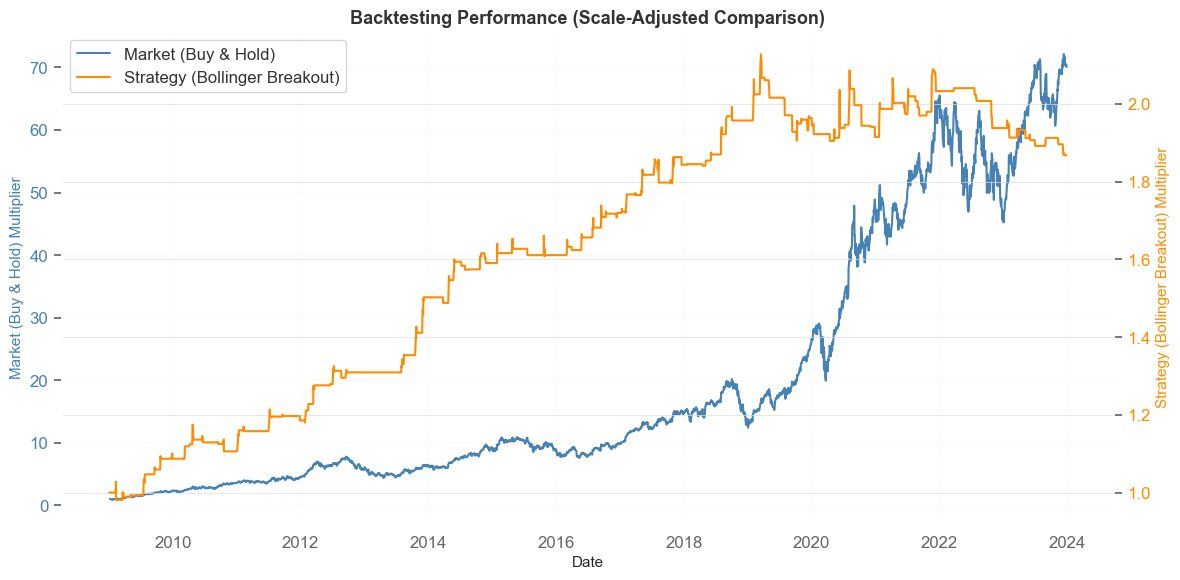

Final Market Growth: 70.08x
Final Strategy Growth: 1.87x


In [76]:
import matplotlib.pyplot as plt
import talib

# 1. Calculate the required Bollinger Bands first
df['upper_band'], df['middle_band'], df['lower_band'] = talib.BBANDS(
    df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0
)

# 2. Run backtest calculations
df['Returns'] = df['Close'].pct_change()
df['Signal'] = 0
df.loc[df['Close'] > df['upper_band'], 'Signal'] = 1
df['Strategy_Returns'] = df['Signal'].shift(1) * df['Returns']

cumulative_market = (1 + df['Returns']).cumprod()
cumulative_strategy = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

# ==============================================================================
# 3. FIX: Plotting with two separate Y-Axes so BOTH lines show detail
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-Axis: Market Growth
color = 'steelblue'
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Market (Buy & Hold) Multiplier', color=color, fontsize=11)
line1 = ax1.plot(cumulative_market, label='Market (Buy & Hold)', color=color, linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)

# Right Y-Axis: Create a secondary axis sharing the same x-axis
ax2 = ax1.twinx()  
color = 'darkorange'
ax2.set_ylabel('Strategy (Bollinger Breakout) Multiplier', color=color, fontsize=11)
line2 = ax2.plot(cumulative_strategy, label='Strategy (Bollinger Breakout)', color=color, linewidth=1.5)
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Backtesting Performance (Scale-Adjusted Comparison)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print out final performance numbers to see the real data
print(f"Final Market Growth: {cumulative_market.iloc[-1]:.2f}x")
print(f"Final Strategy Growth: {cumulative_strategy.iloc[-1]:.2f}x")

In [74]:
# 1. Check if any buy signals were generated
num_signals = df['Signal'].sum()
print(f"Total days spent invested in the strategy: {num_signals} days")

# 2. Look at the raw strategy returns to see if they are all 0
print("\nFirst 10 days of strategy returns:")
print(df['Strategy_Returns'].dropna().head(10))

KeyError: 'Signal'

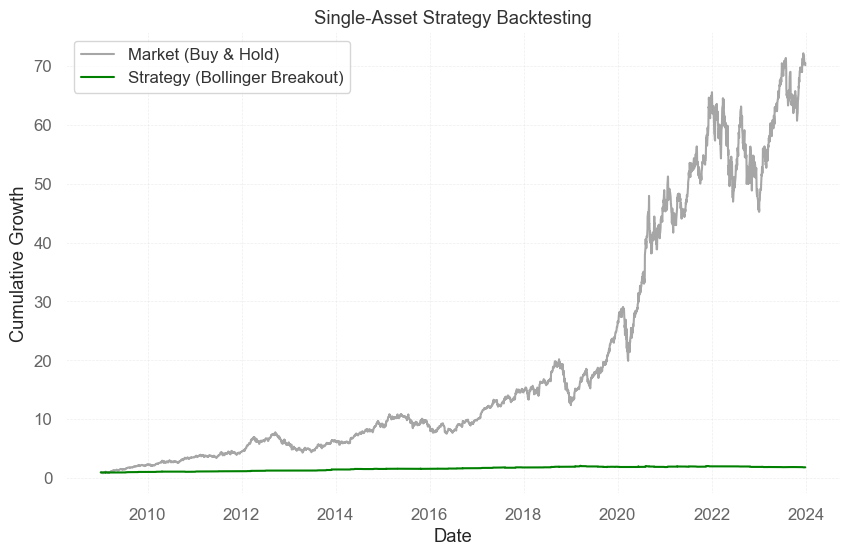

In [73]:
perf_df= backtest_bollinger_breakout(df)

KeyError: 'Market_Cum'

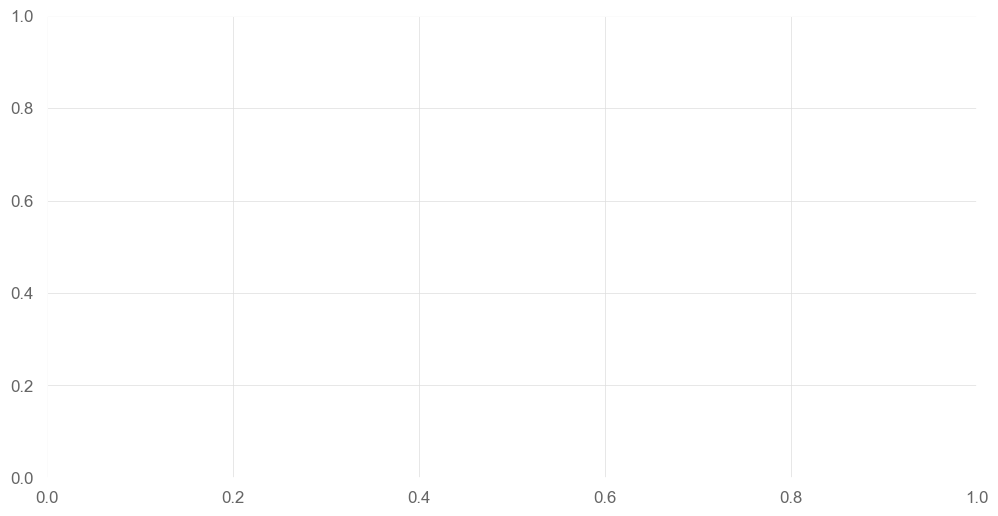

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(perf_df4.index, perf_df4['Market_Cum'], label='Market (Buy & Hold)', color='steelblue', linewidth=1.5)
ax.plot(perf_df4.index, perf_df4['Strategy_Cum'], label='Strategy (Bollinger Breakout)', color='crimson', linewidth=1.5)

ax.set_title("Dataset 2: Backtesting Performance Comparison", fontsize=13, fontweight='bold')
ax.set_ylabel("Cumulative Growth (Multiplier)")
ax.set_xlabel("Date")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [68]:
import matplotlib.pyplot as plt
import src.analysis as ana  # Force reload if you just saved the .py file

# 1. Run the backtest engine
perf_df = ana.backtest_bollinger_breakout(df)

# 2. Plot the results from the notebook
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(perf_df.index, perf_df['Market_Cum'], label='Market (Buy & Hold)', color='steelblue', linewidth=1.5)
ax.plot(perf_df.index, perf_df['Strategy_Cum'], label='Strategy (Bollinger Breakout)', color='darkorange', linewidth=1.5)

ax.set_title("Dataset 1: Backtesting Performance Comparison", fontsize=13, fontweight='bold')
ax.set_ylabel("Cumulative Growth (Multiplier)")
ax.set_xlabel("Date")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

KeyError: 'upper_band'

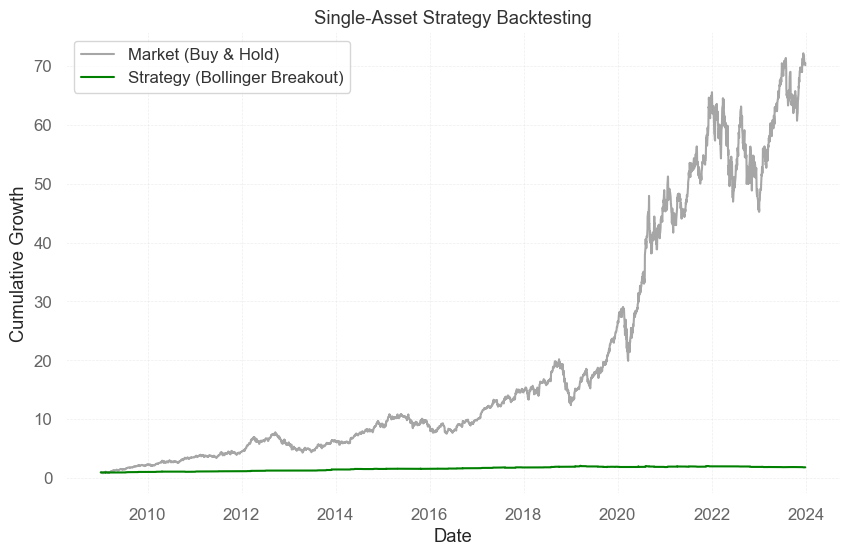

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 1.14
Max Drawdown: -43.80%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,298,695,245,824
Trailing PE: 35.476364
----------------------------------------


In [16]:
#for 1st dataset-AAPL
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

 
df['upper_band'], df['middle_band'], df['lower_band'] = talib.BBANDS(
    df['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df_results = backtest_bollinger_breakout(df, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

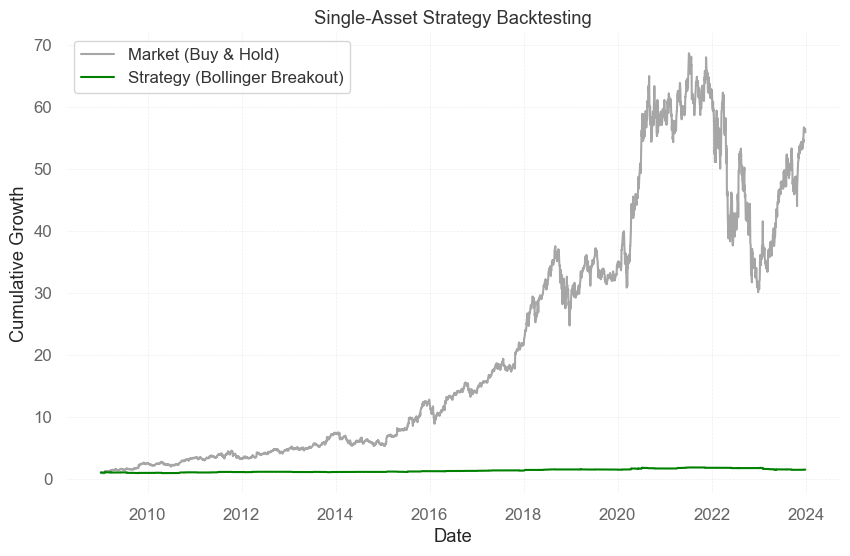

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 1.14
Max Drawdown: -43.80%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,278,867,197,952
Trailing PE: 35.227325
----------------------------------------


In [27]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df2['upper_band'], df2['middle_band'], df2['lower_band'] = talib.BBANDS(
    df2['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df2_results = backtest_bollinger_breakout(df2, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

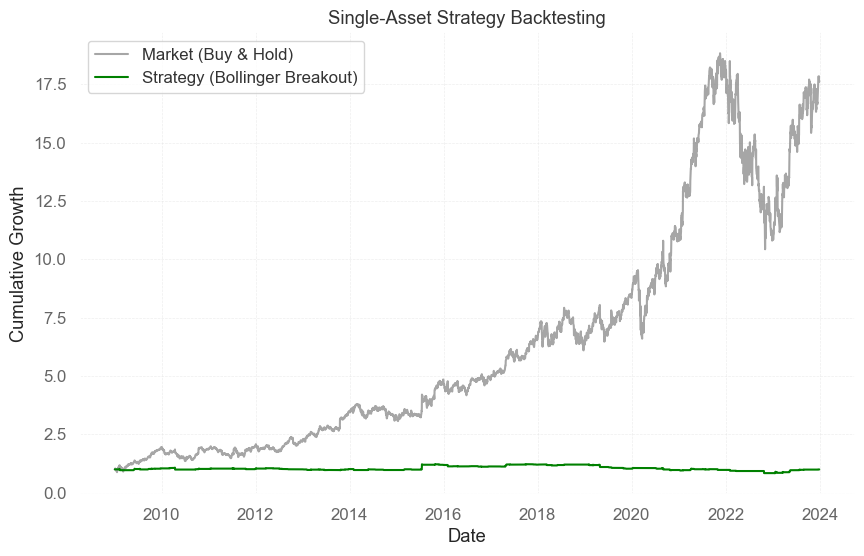

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 0.83
Max Drawdown: -44.60%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,279,454,924,800
Trailing PE: 35.232162
----------------------------------------


In [28]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df3['upper_band'], df3['middle_band'], df3['lower_band'] = talib.BBANDS(
    df3['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df3_results = backtest_bollinger_breakout(df3, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df3['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

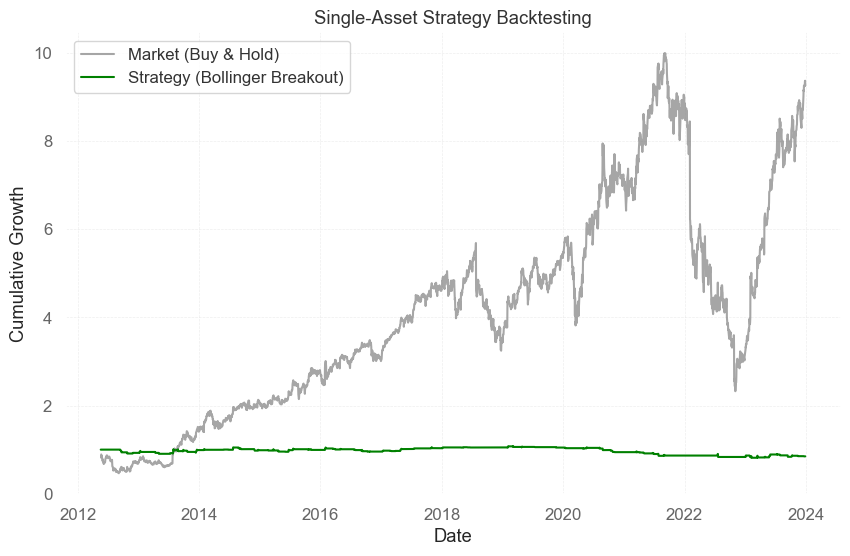

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 0.68
Max Drawdown: -76.74%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,279,014,260,736
Trailing PE: 35.228535
----------------------------------------


In [29]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df4['upper_band'], df4['middle_band'], df4['lower_band'] = talib.BBANDS(
    df4['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df4_results = backtest_bollinger_breakout(df4, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df4['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

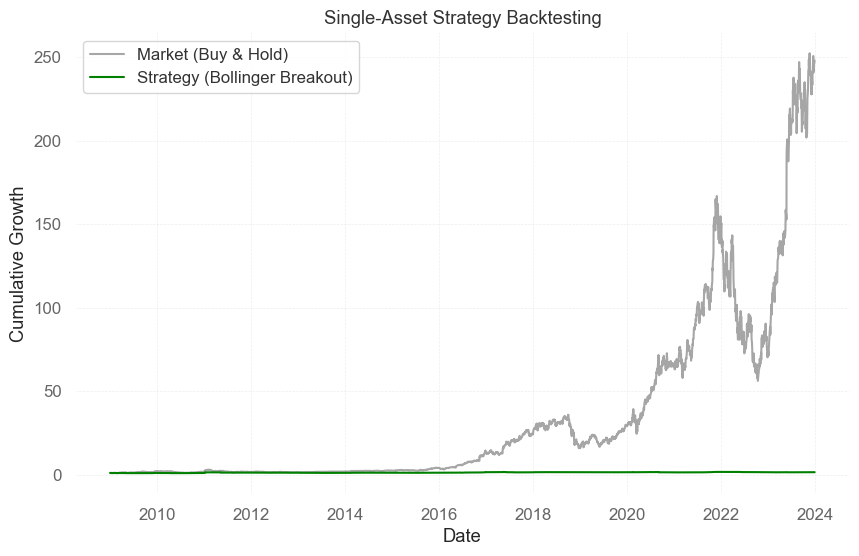

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 1.14
Max Drawdown: -43.80%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,288,340,819,968
Trailing PE: 35.30532
----------------------------------------


In [30]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df5['upper_band'], df5['middle_band'], df5['lower_band'] = talib.BBANDS(
    df5['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df5_results = backtest_bollinger_breakout(df5, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

Now lets go to visualizing

Plot closing prices overlaid with moving averages 

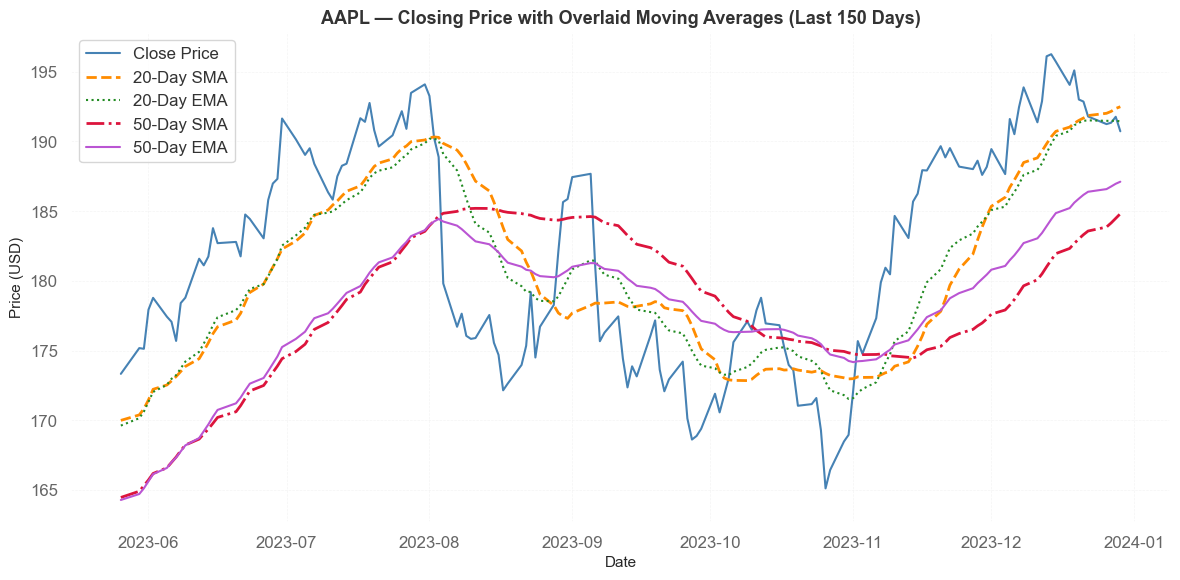

In [17]:
import matplotlib.pyplot as plt

# 1. Create the figure and a single axis object (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot your Close Price and Moving Averages using your ax1 syntax
# Slicing the last 150 days ensures the lines are clearly seen and not piled up
ax1.plot(df.index[-150:], df['Close'][-150:], label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(df.index[-150:], df['SMA_20'][-150:], label='20-Day SMA', color='darkorange', linewidth=2, linestyle='--')
ax1.plot(df.index[-150:], df['EMA_20'][-150:], label='20-Day EMA', color='forestgreen', linewidth=1.5, linestyle=':')
ax1.plot(df.index[-150:], df['SMA_50'][-150:], label='50-Day SMA', color='crimson', linewidth=2, linestyle='-.')
ax1.plot(df.index[-150:], df['EMA_50'][-150:], label='50-Day EMA', color='mediumorchid', linewidth=1.5, linestyle='-')

# 3. Add titles, labels, grid, and legend using the axis object
ax1.set_title('AAPL — Closing Price with Overlaid Moving Averages (Last 150 Days)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='upper left')

# 4. Display the clean chart
plt.tight_layout()
plt.show()

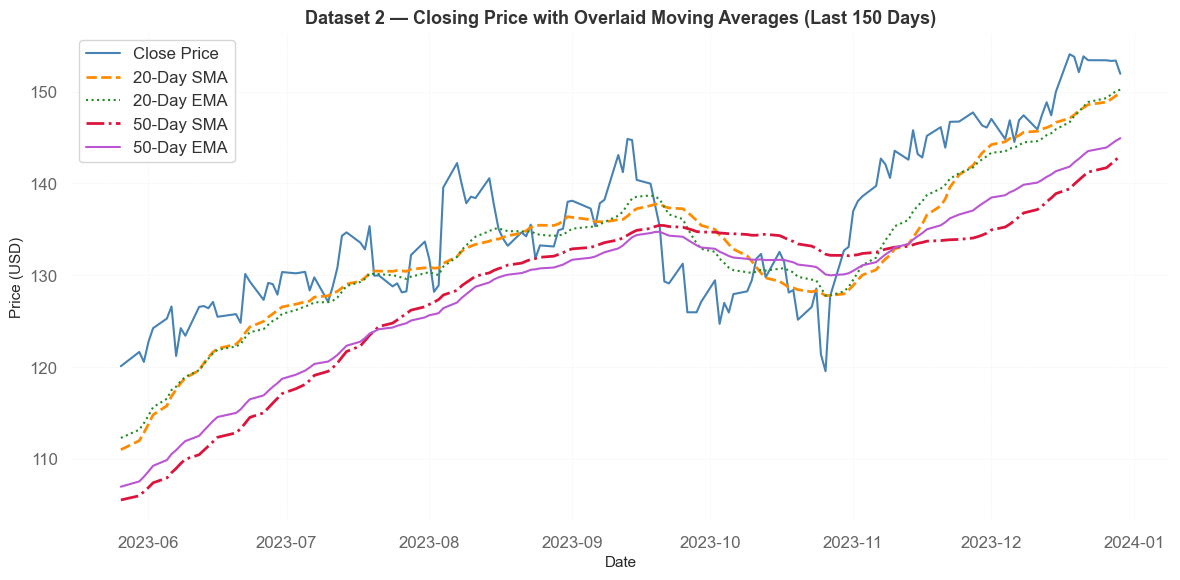

In [23]:
import matplotlib.pyplot as plt

# 1. Create the figure and a single axis object (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot your Close Price and Moving Averages using your ax1 syntax
# Slicing the last 150 days ensures the lines are clearly seen and not piled up
ax1.plot(df2.index[-150:], df2['Close'][-150:], label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(df2.index[-150:], df2['SMA_20'][-150:], label='20-Day SMA', color='darkorange', linewidth=2, linestyle='--')
ax1.plot(df2.index[-150:], df2['EMA_20'][-150:], label='20-Day EMA', color='forestgreen', linewidth=1.5, linestyle=':')
ax1.plot(df2.index[-150:], df2['SMA_50'][-150:], label='50-Day SMA', color='crimson', linewidth=2, linestyle='-.')
ax1.plot(df2.index[-150:], df2['EMA_50'][-150:], label='50-Day EMA', color='mediumorchid', linewidth=1.5, linestyle='-')

# 3. Add titles, labels, grid, and legend using the axis object
ax1.set_title('Dataset 2 — Closing Price with Overlaid Moving Averages (Last 150 Days)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='upper left')

# 4. Display the clean chart
plt.tight_layout()
plt.show()

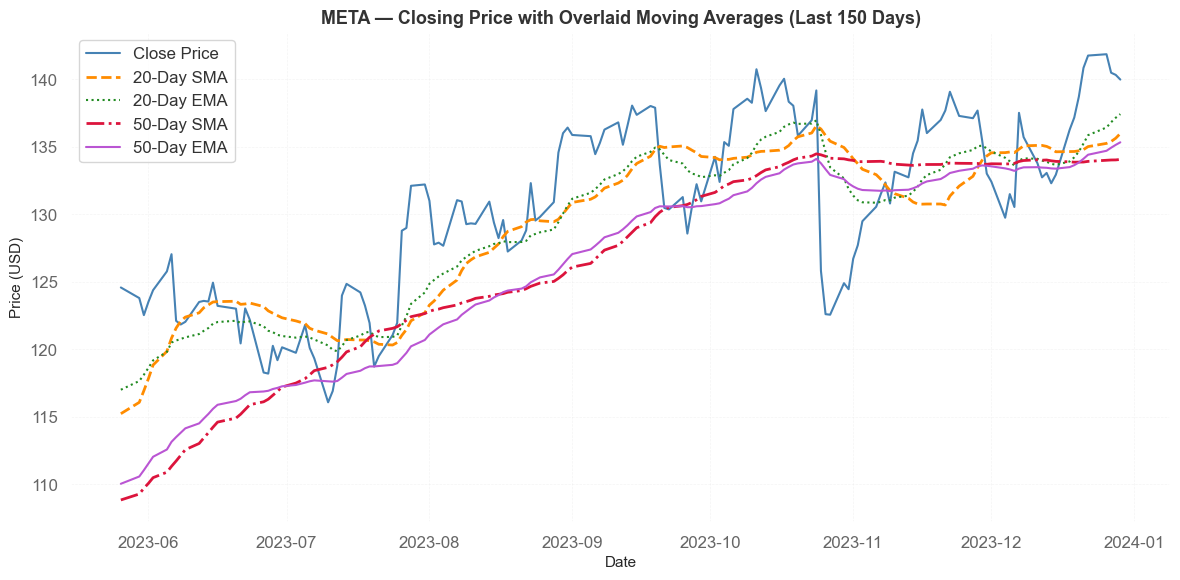

In [24]:
###For META
import matplotlib.pyplot as plt

# 1. Create the figure and a single axis object (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot your Close Price and Moving Averages using your ax1 syntax
# Slicing the last 150 days ensures the lines are clearly seen and not piled up
ax1.plot(df3.index[-150:], df3['Close'][-150:], label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(df3.index[-150:], df3['SMA_20'][-150:], label='20-Day SMA', color='darkorange', linewidth=2, linestyle='--')
ax1.plot(df3.index[-150:], df3['EMA_20'][-150:], label='20-Day EMA', color='forestgreen', linewidth=1.5, linestyle=':')
ax1.plot(df3.index[-150:], df3['SMA_50'][-150:], label='50-Day SMA', color='crimson', linewidth=2, linestyle='-.')
ax1.plot(df3.index[-150:], df3['EMA_50'][-150:], label='50-Day EMA', color='mediumorchid', linewidth=1.5, linestyle='-')

# 3. Add titles, labels, grid, and legend using the axis object
ax1.set_title('META — Closing Price with Overlaid Moving Averages (Last 150 Days)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='upper left')

# 4. Display the clean chart
plt.tight_layout()
plt.show()

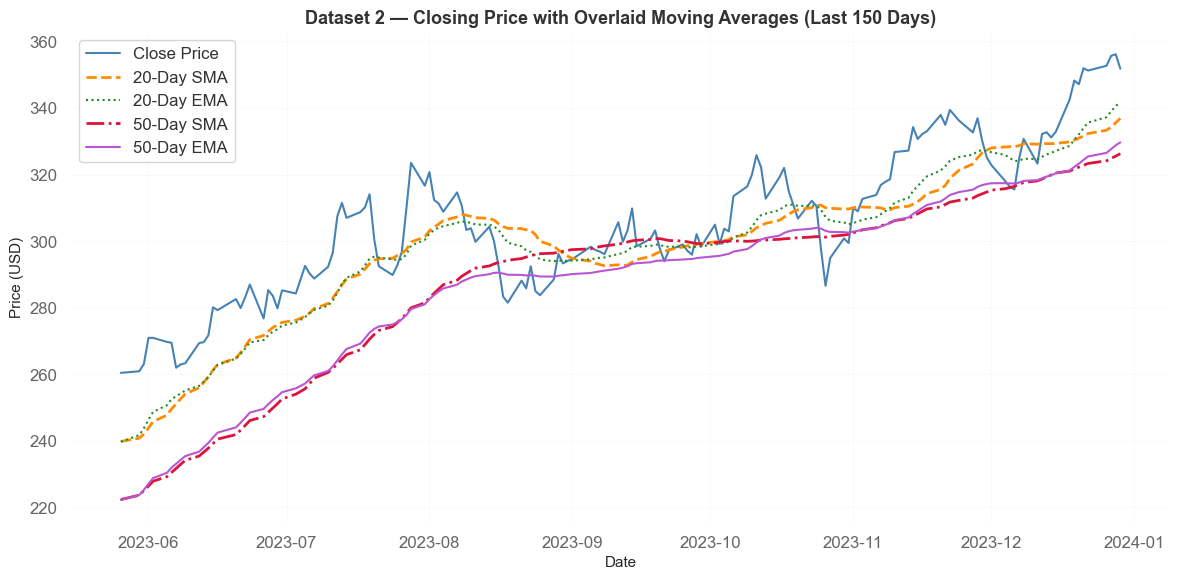

In [25]:
import matplotlib.pyplot as plt

# 1. Create the figure and a single axis object (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot your Close Price and Moving Averages using your ax1 syntax
# Slicing the last 150 days ensures the lines are clearly seen and not piled up
ax1.plot(df4.index[-150:], df4['Close'][-150:], label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(df4.index[-150:], df4['SMA_20'][-150:], label='20-Day SMA', color='darkorange', linewidth=2, linestyle='--')
ax1.plot(df4.index[-150:], df4['EMA_20'][-150:], label='20-Day EMA', color='forestgreen', linewidth=1.5, linestyle=':')
ax1.plot(df4.index[-150:], df4['SMA_50'][-150:], label='50-Day SMA', color='crimson', linewidth=2, linestyle='-.')
ax1.plot(df4.index[-150:], df4['EMA_50'][-150:], label='50-Day EMA', color='mediumorchid', linewidth=1.5, linestyle='-')

# 3. Add titles, labels, grid, and legend using the axis object
ax1.set_title('Dataset 2 — Closing Price with Overlaid Moving Averages (Last 150 Days)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='upper left')

# 4. Display the clean chart
plt.tight_layout()
plt.show()

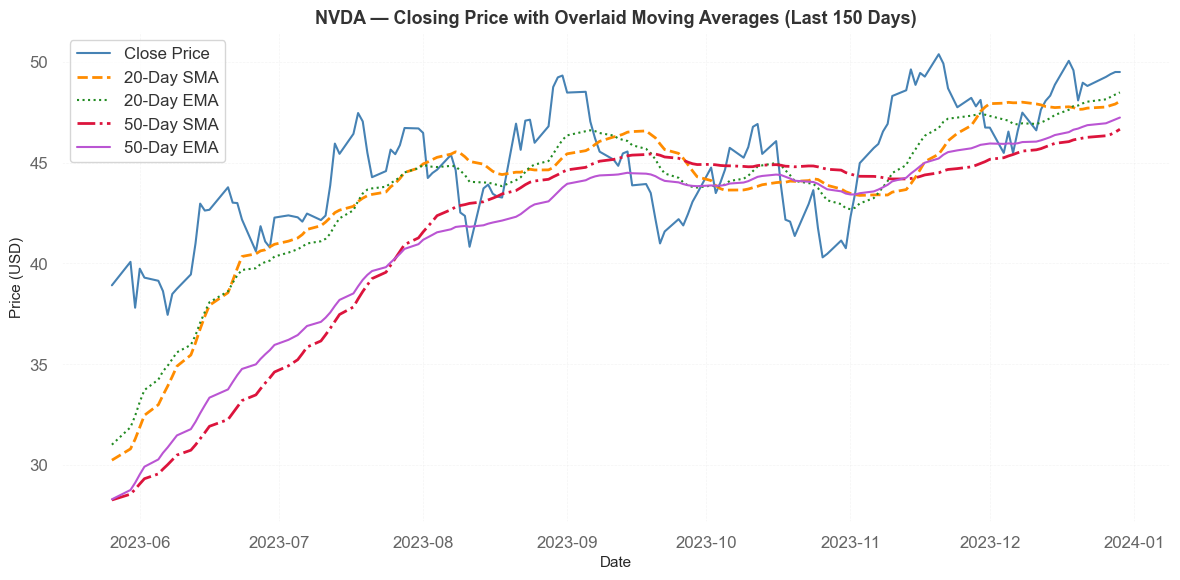

In [28]:
import matplotlib.pyplot as plt

# 1. Create the figure and a single axis object (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot your Close Price and Moving Averages using your ax1 syntax
# Slicing the last 150 days ensures the lines are clearly seen and not piled up
ax1.plot(df5.index[-150:], df5['Close'][-150:], label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(df5.index[-150:], df5['SMA_20'][-150:], label='20-Day SMA', color='darkorange', linewidth=2, linestyle='--')
ax1.plot(df5.index[-150:], df5['EMA_20'][-150:], label='20-Day EMA', color='forestgreen', linewidth=1.5, linestyle=':')
ax1.plot(df5.index[-150:], df5['SMA_50'][-150:], label='50-Day SMA', color='crimson', linewidth=2, linestyle='-.')
ax1.plot(df5.index[-150:], df5['EMA_50'][-150:], label='50-Day EMA', color='mediumorchid', linewidth=1.5, linestyle='-')

# 3. Add titles, labels, grid, and legend using the axis object
ax1.set_title('NVDA — Closing Price with Overlaid Moving Averages (Last 150 Days)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='upper left')

# 4. Display the clean chart
plt.tight_layout()
plt.show()

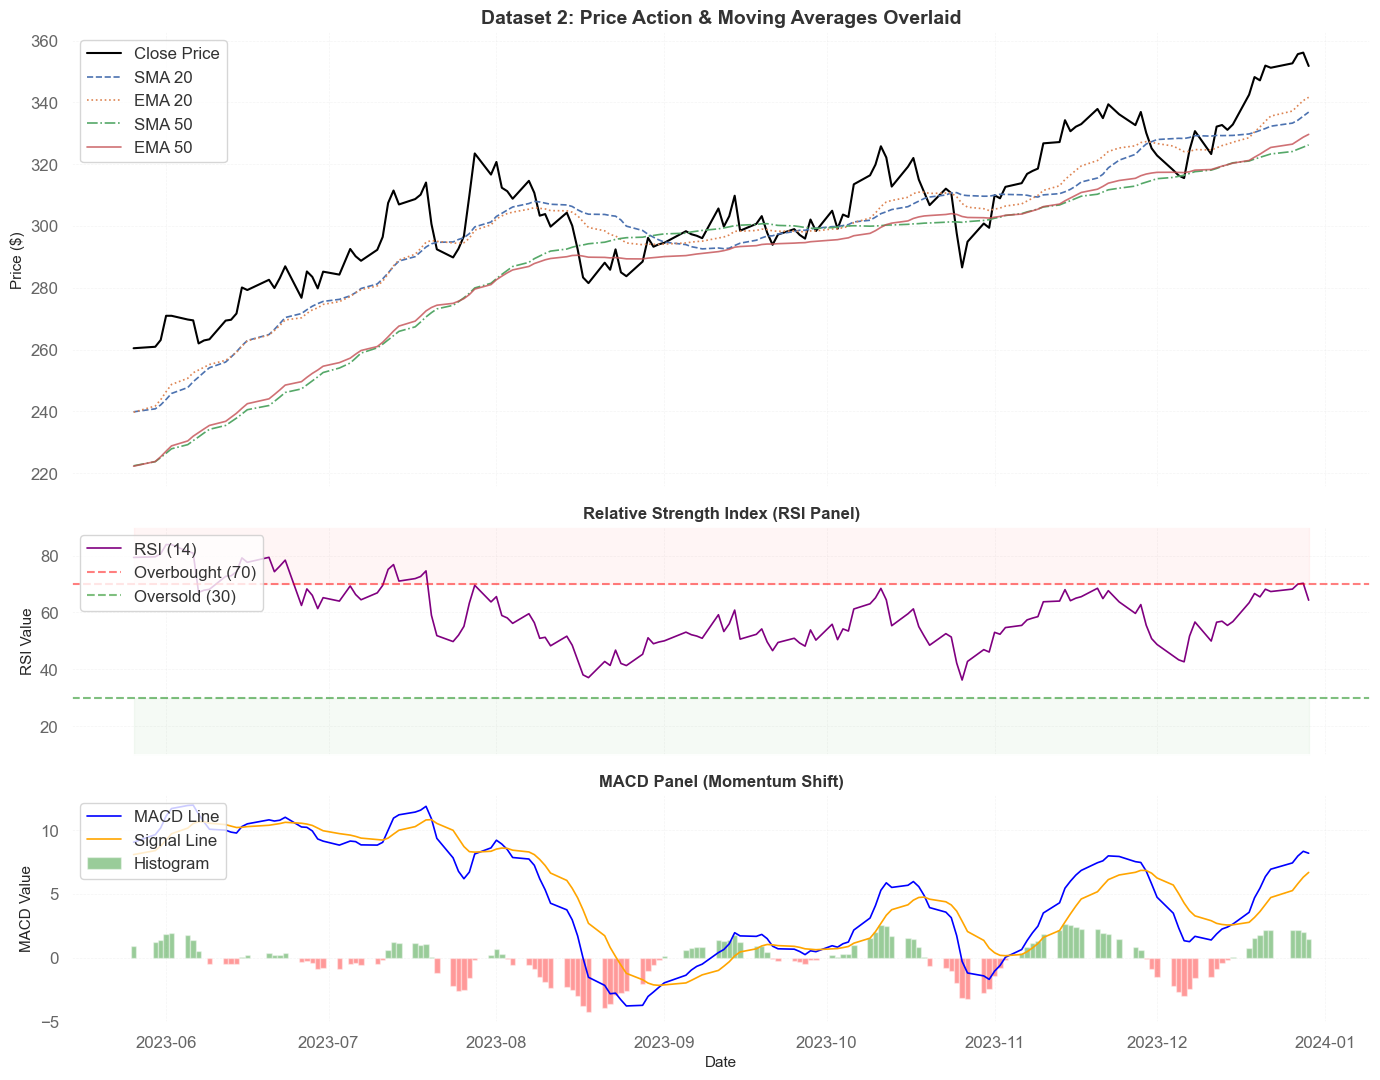

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Define your lookback window to keep the lines beautifully distinct and uncrowded
# [-150:] shows the last 150 trading days, which gives the data excellent breathing room
WINDOW = -150 

# Create 3 stacked panels sharing the exact same X-axis (Dates)
fig, axes = plt.subplots(
    3, 1, 
    figsize=(14, 11), 
    sharex=True, 
    gridspec_kw={'height_ratios': [2, 1, 1]} # Gives the main price panel more visual weight
)

# ==============================================================================
# PANEL 1: Closing Prices Overlaid with Moving Averages
# ==============================================================================
axes[0].plot(df4.index[WINDOW:], df4['Close'][WINDOW:], label='Close Price', color='black', linewidth=1.5)
axes[0].plot(df4.index[WINDOW:], df4['SMA_20'][WINDOW:], label='SMA 20', linestyle='--', linewidth=1.2)
axes[0].plot(df4.index[WINDOW:], df4['EMA_20'][WINDOW:], label='EMA 20', linestyle=':', linewidth=1.2)
axes[0].plot(df4.index[WINDOW:], df4['SMA_50'][WINDOW:], label='SMA 50', linestyle='-.', linewidth=1.2)
axes[0].plot(df4.index[WINDOW:], df4['EMA_50'][WINDOW:], label='EMA 50', linestyle='-', linewidth=1.2, alpha=0.8)

axes[0].set_title("Dataset 2: Price Action & Moving Averages Overlaid", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Price ($)", fontsize=11)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.3)

# ==============================================================================
# PANEL 2: RSI in a Separate Panel
# ==============================================================================
axes[1].plot(df4.index[WINDOW:], df4['RSI_14'][WINDOW:], color='purple', label='RSI (14)', linewidth=1.2)

# Standard Overbought (70) and Oversold (30) boundary lines
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')

# Soft background fills for the threshold zones to make them stand out clearly
axes[1].fill_between(df4.index[WINDOW:], 70, 100, color='red', alpha=0.04)
axes[1].fill_between(df4.index[WINDOW:], 0, 30, color='green', alpha=0.04)

axes[1].set_title("Relative Strength Index (RSI Panel)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("RSI Value", fontsize=11)
axes[1].set_ylim(10, 90)
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.3)

# ==============================================================================
# PANEL 3: MACD in a Separate Panel
# ==============================================================================
axes[2].plot(df4.index[WINDOW:], df4['MACD'][WINDOW:], label='MACD Line', color='blue', linewidth=1.2)
axes[2].plot(df4.index[WINDOW:], df4['MACD_Signal'][WINDOW:], label='Signal Line', color='orange', linewidth=1.2)

# Color-coded Histogram bars (Green for positive momentum, Red for negative momentum)
hist_slice = df4['MACD_Hist'][WINDOW:]
positive_hist = hist_slice > 0
bar_colors = np.where(positive_hist, 'green', 'red')
axes[2].bar(df4.index[WINDOW:], hist_slice, label='Histogram', color=bar_colors, alpha=0.4, width=1.0)

axes[2].set_title("MACD Panel (Momentum Shift)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("MACD Value", fontsize=11)
axes[2].set_xlabel("Date", fontsize=11)
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle='--', alpha=0.3)

# Clean up layout spacing and render
plt.tight_layout()
plt.show()

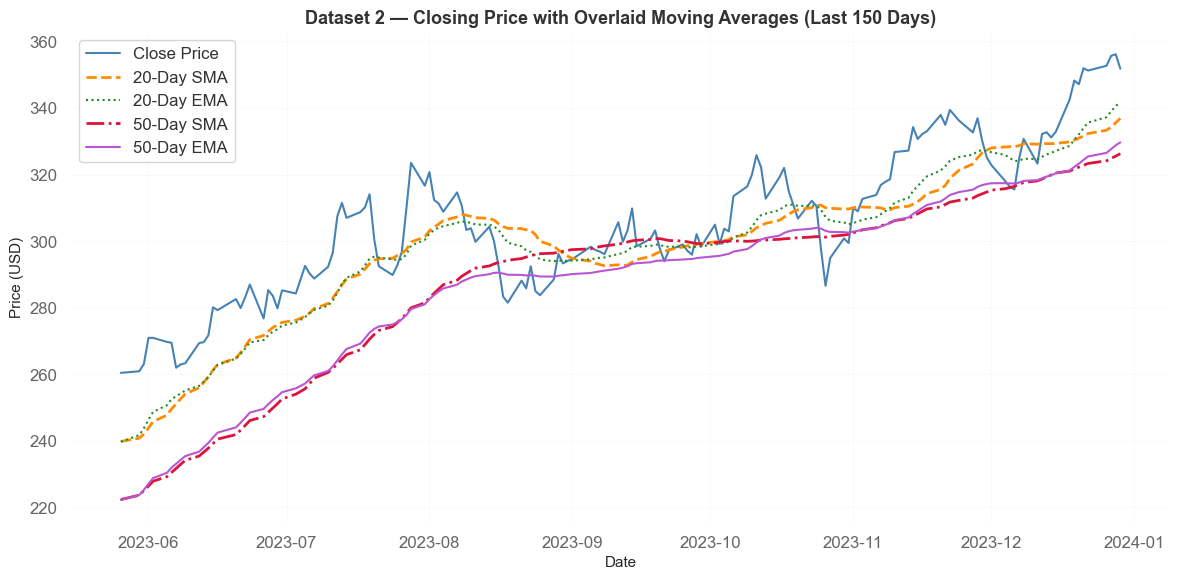